In [1]:
import pandas as pd
data = pd.read_csv(r'C:\Users\mbpd1\Downloads\scaler\portfolio_project\data\insurance.csv')
data['BMI'] = data['Weight'] / (data['Height'] / 100) ** 2
data.to_csv(r'C:\Users\mbpd1\Downloads\scaler\portfolio_project\data\insurance_with_bmi.csv', index=False)

In [2]:
import pandas as pd
data = pd.read_csv(r'C:\Users\mbpd1\Downloads\scaler\portfolio_project\data\insurance_with_bmi.csv')
corr = data[['Age', 'Height', 'Weight', 'NumberOfMajorSurgeries', 'PremiumPrice', 'BMI']].corr()
corr.to_csv(r'C:\Users\mbpd1\Downloads\scaler\portfolio_project\data\correlations.csv')

Missing Values:
 Age                        0
Diabetes                   0
BloodPressureProblems      0
AnyTransplants             0
AnyChronicDiseases         0
Height                     0
Weight                     0
KnownAllergies             0
HistoryOfCancerInFamily    0
NumberOfMajorSurgeries     0
PremiumPrice               0
BMI                        0
dtype: int64


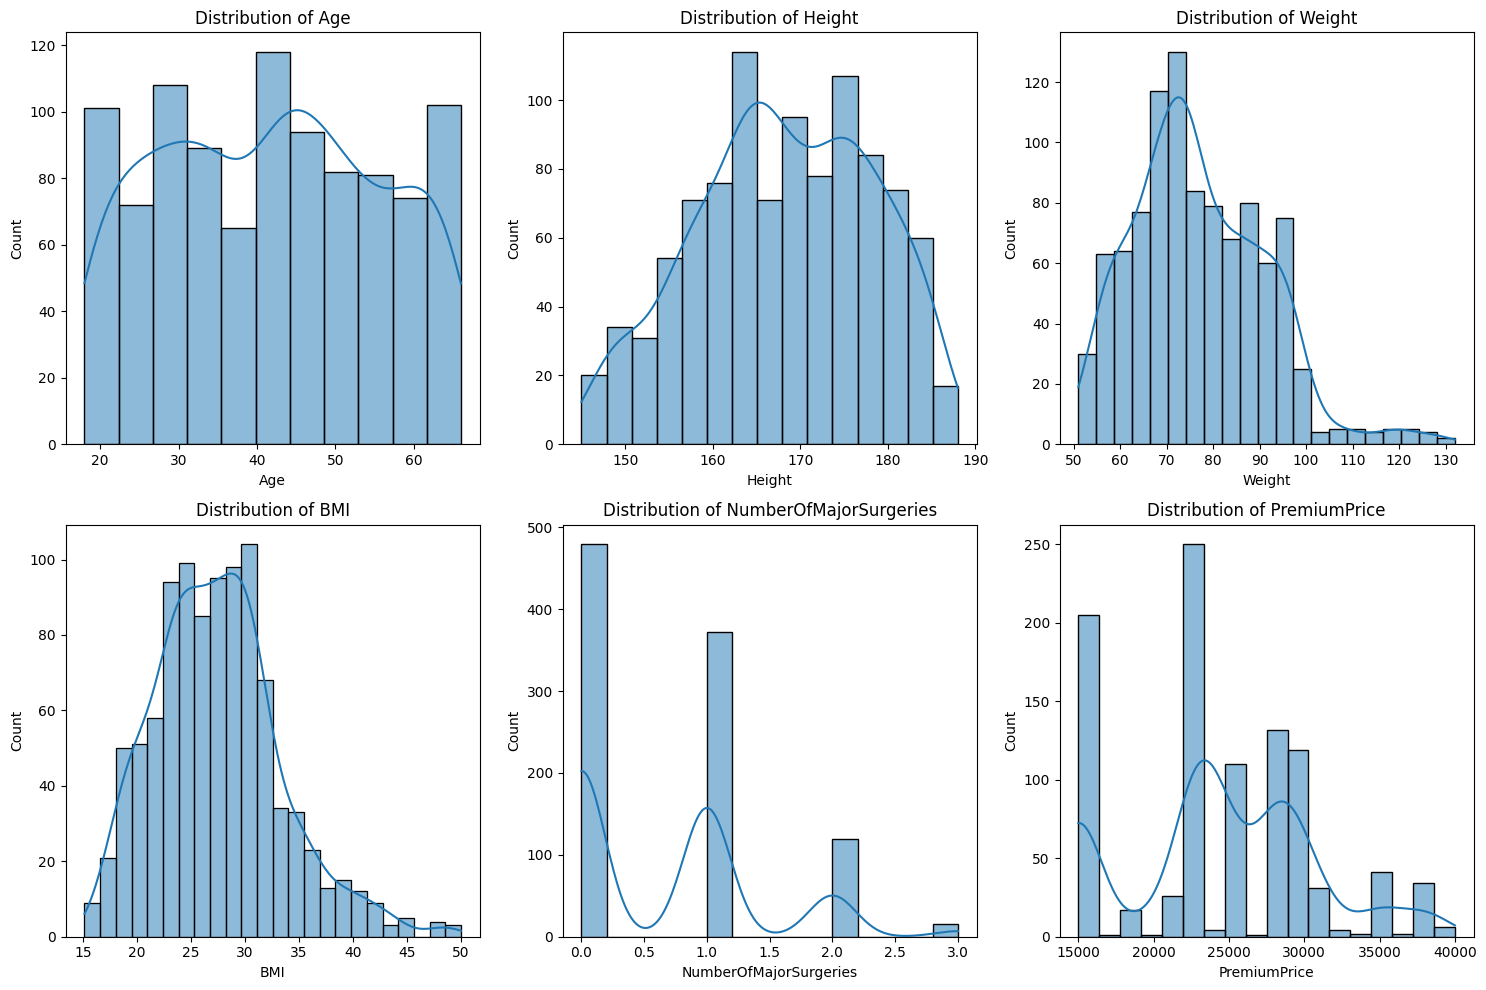

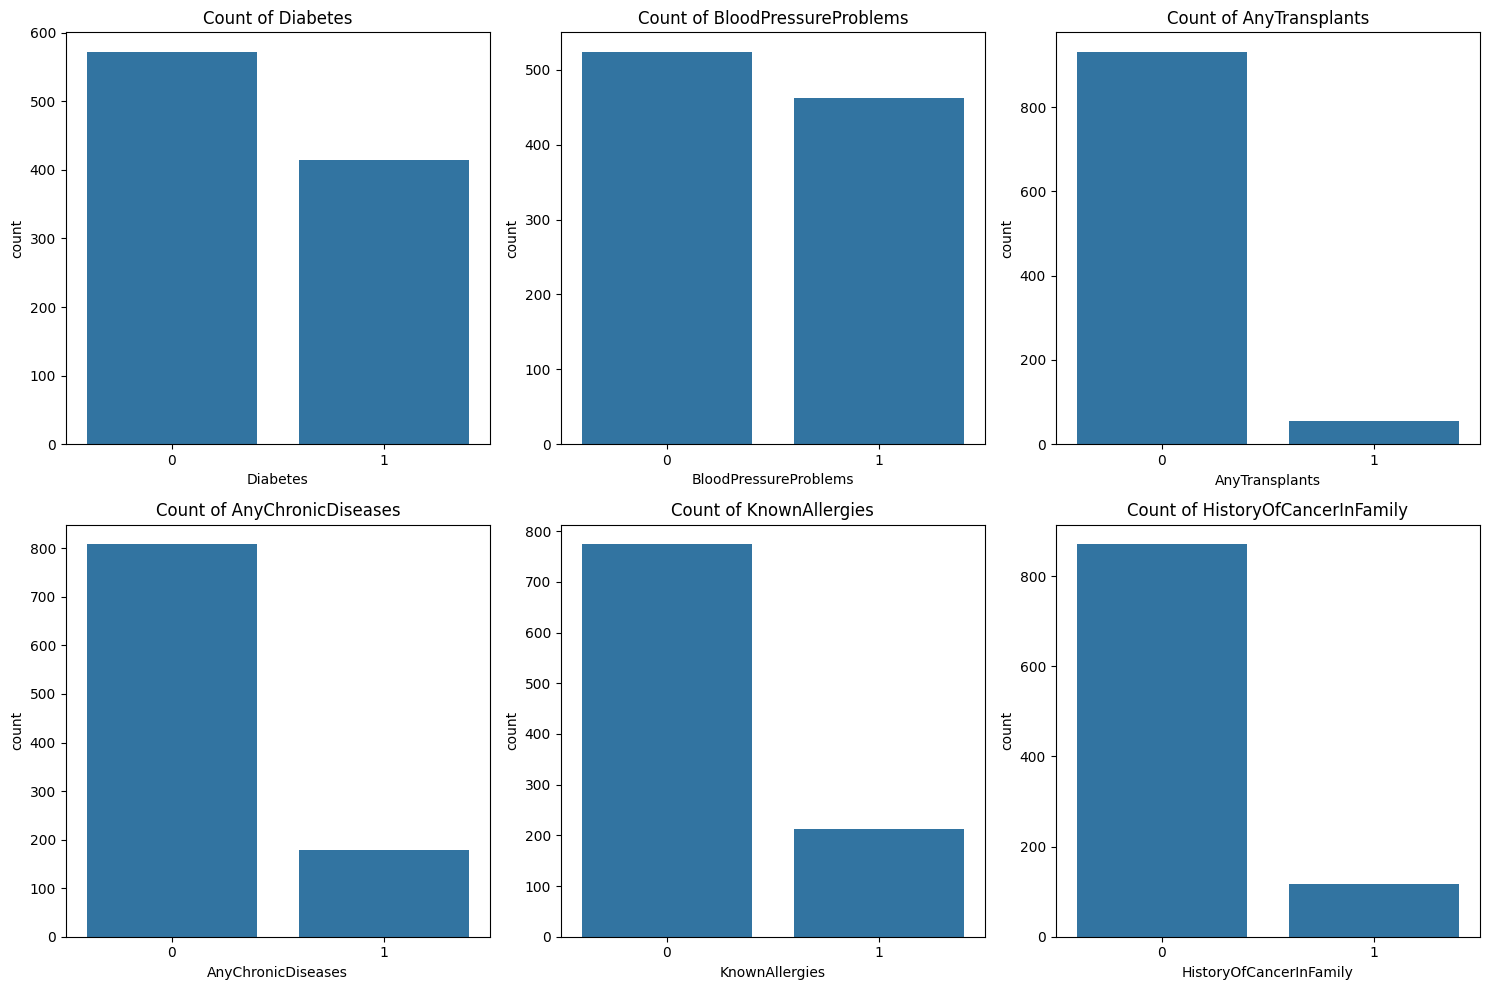

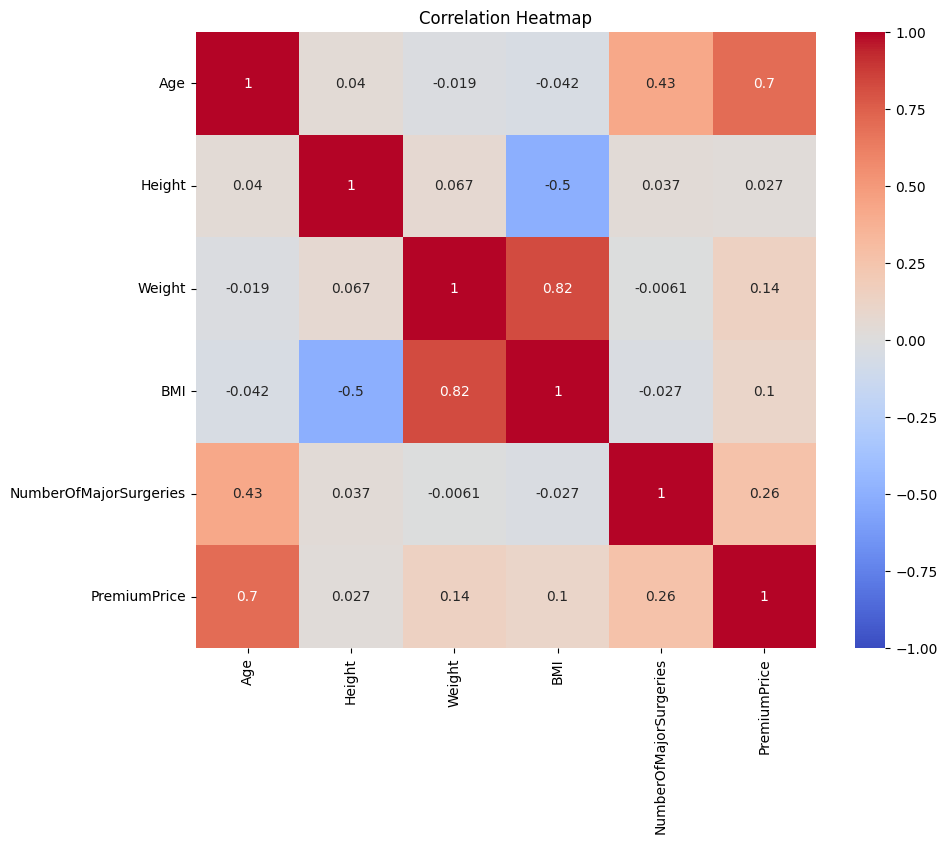

Outliers in PremiumPrice:
 204    39000
295    40000
926    39000
928    39000
976    39000
984    39000
Name: PremiumPrice, dtype: int64
Outliers in BMI:
 24     42.541994
26     42.541994
99     44.284149
133    42.666667
154    47.872125
158    48.469797
175    44.200579
183    48.898751
186    43.102008
187    44.220861
192    47.800068
195    49.077930
203    42.767884
204    47.466477
209    42.968750
218    44.988102
225    50.000000
228    44.273479
766    42.340435
775    41.890005
789    42.666667
796    42.541994
Name: BMI, dtype: float64


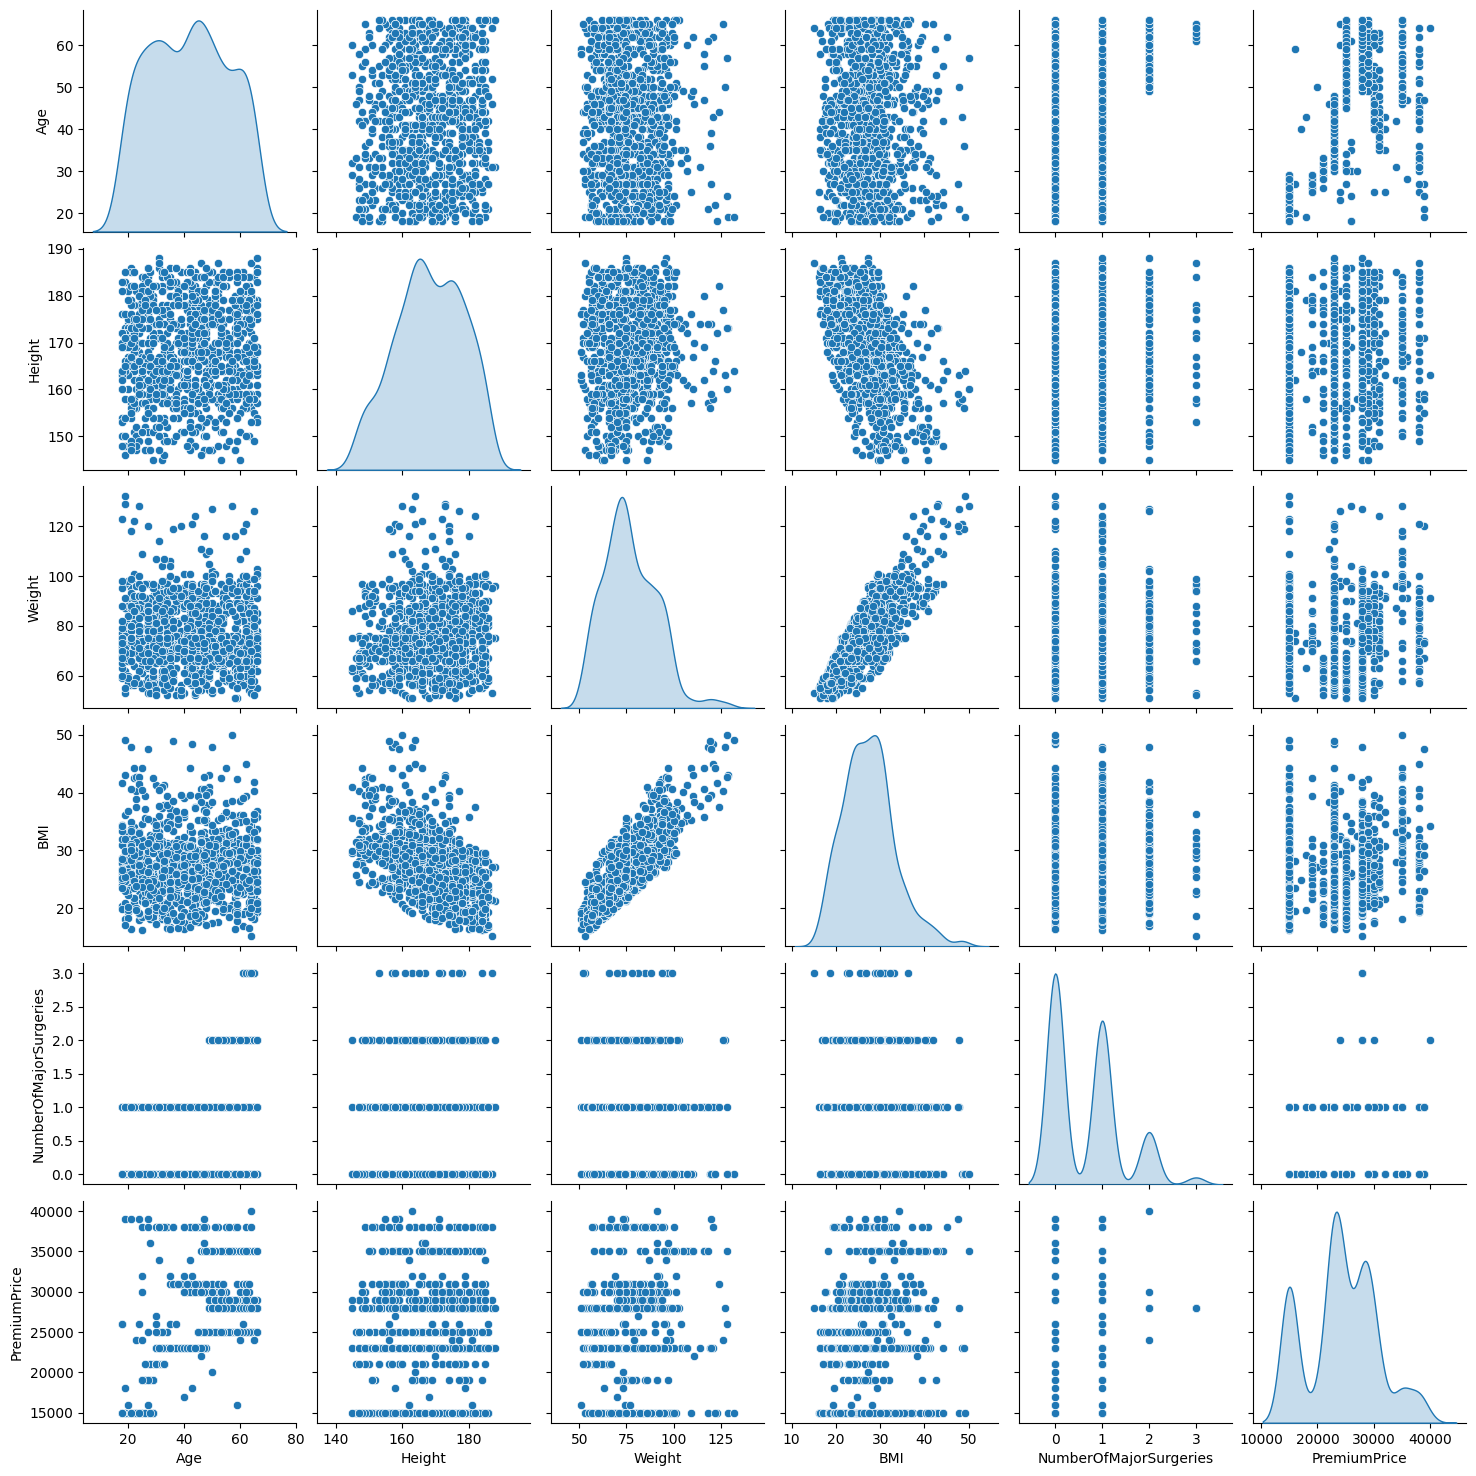

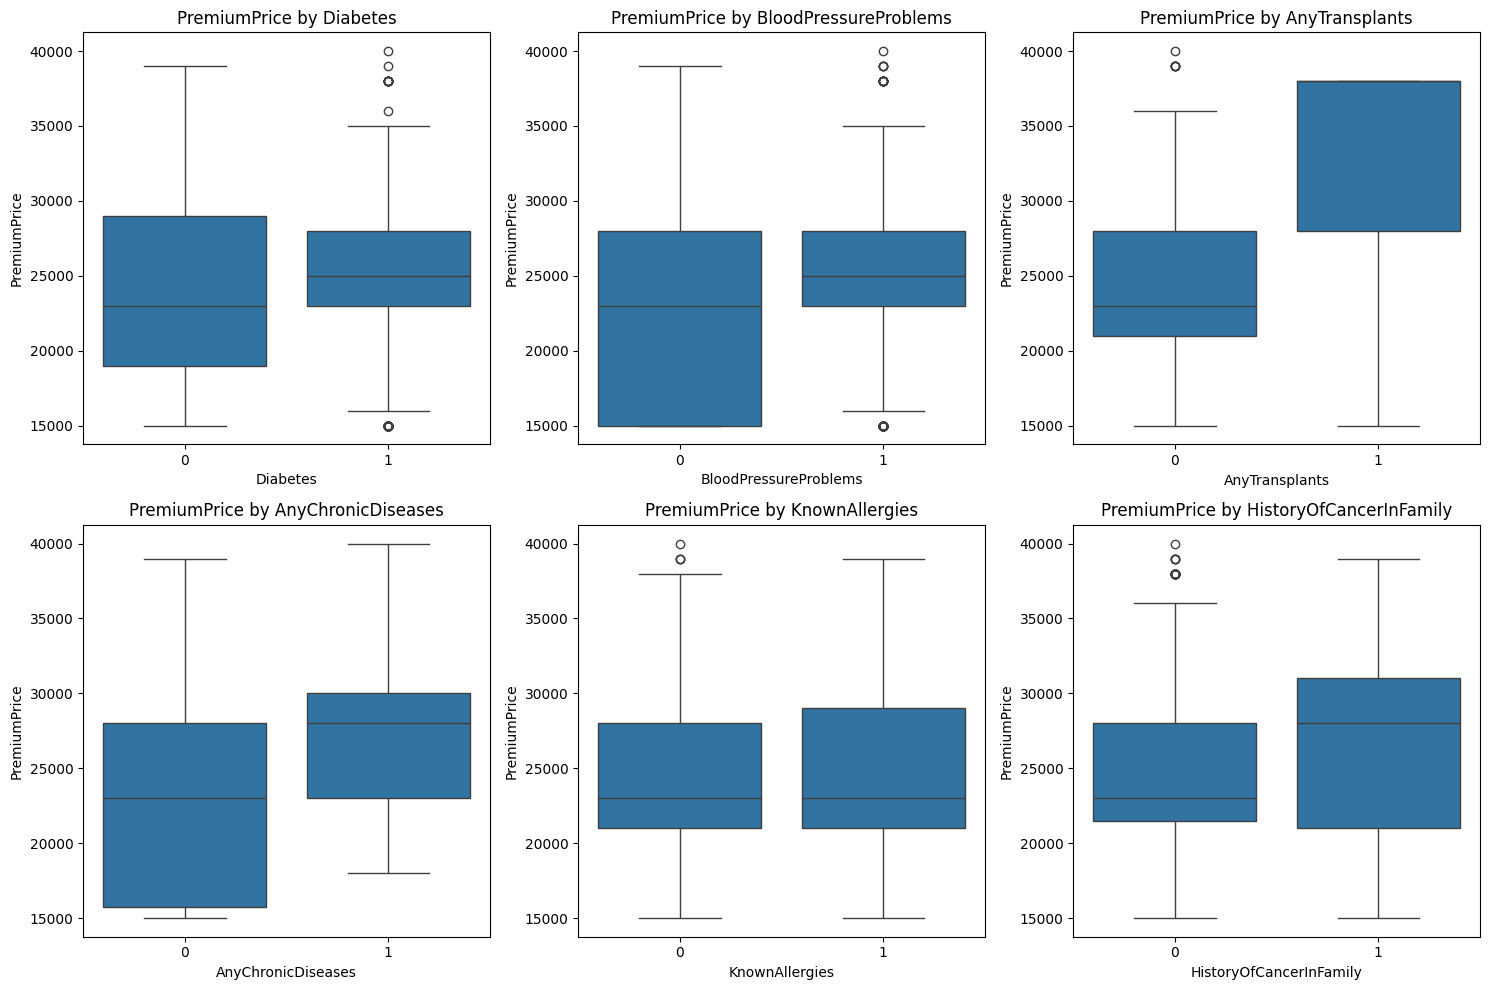

In [3]:
# Artifact: EDA for Insurance Cost Prediction

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load dataset
data = pd.read_csv(r'C:\Users\mbpd1\Downloads\scaler\portfolio_project\data\insurance.csv')

# Calculate BMI
data['BMI'] = data['Weight'] / (data['Height'] / 100) ** 2

# Check for missing values
print("Missing Values:\n", data.isnull().sum())

# Distribution Analysis: Numerical Variables
numerical_cols = ['Age', 'Height', 'Weight', 'BMI', 'NumberOfMajorSurgeries', 'PremiumPrice']
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.savefig(r'C:\Users\mbpd1\Downloads\scaler\portfolio_project\images\numerical_distributions.png')
plt.show()

# Distribution Analysis: Categorical Variables
categorical_cols = ['Diabetes', 'BloodPressureProblems', 'AnyTransplants', 'AnyChronicDiseases', 
                   'KnownAllergies', 'HistoryOfCancerInFamily']
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=col, data=data)
    plt.title(f'Count of {col}')
plt.tight_layout()
plt.savefig(r'C:\Users\mbpd1\Downloads\scaler\portfolio_project\images\categorical_distributions.png')
plt.show()

# Correlation Analysis
plt.figure(figsize=(10, 8))
corr = data[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.savefig(r'C:\Users\mbpd1\Downloads\scaler\portfolio_project\images\correlation_heatmap.png')
plt.show()

# Outlier Detection (IQR Method)
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    return outliers

# Check outliers for PremiumPrice and BMI
for col in ['PremiumPrice', 'BMI']:
    outliers = detect_outliers_iqr(data, col)
    print(f"Outliers in {col}:\n", outliers)

# Pair Plot
sns.pairplot(data[numerical_cols], diag_kind='kde')
plt.savefig(r'C:\Users\mbpd1\Downloads\scaler\portfolio_project\images\pair_plot.png')
plt.show()

# Boxplots by Categorical Variables
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=col, y='PremiumPrice', data=data)
    plt.title(f'PremiumPrice by {col}')
plt.tight_layout()
plt.savefig(r'C:\Users\mbpd1\Downloads\scaler\portfolio_project\images\boxplots_by_categorical.png')
plt.show()

In [4]:
# Artifact: Hypothesis Testing for Insurance Cost Prediction

from scipy.stats import ttest_ind, f_oneway

# H1: PremiumPrice for Diabetes=1 vs. Diabetes=0
diabetes_yes = data[data['Diabetes'] == 1]['PremiumPrice']
diabetes_no = data[data['Diabetes'] == 0]['PremiumPrice']
t_stat, p_value = ttest_ind(diabetes_yes, diabetes_no)
print("H1: Diabetes vs. PremiumPrice")
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject null: Premiums are significantly higher for diabetic individuals.")
else:
    print("Fail to reject null.")

# H2: PremiumPrice for AnyChronicDiseases=1 vs. AnyChronicDiseases=0
chronic_yes = data[data['AnyChronicDiseases'] == 1]['PremiumPrice']
chronic_no = data[data['AnyChronicDiseases'] == 0]['PremiumPrice']
t_stat, p_value = ttest_ind(chronic_yes, chronic_no)
print("\nH2: Chronic Diseases vs. PremiumPrice")
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject null: Premiums are significantly higher for individuals with chronic diseases.")
else:
    print("Fail to reject null.")

# H3: PremiumPrice by NumberOfMajorSurgeries
groups = [data[data['NumberOfMajorSurgeries'] == i]['PremiumPrice'] for i in range(4)]
f_stat, p_value = f_oneway(*groups)
print("\nH3: NumberOfMajorSurgeries vs. PremiumPrice")
print(f"F-statistic: {f_stat:.4f}, P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject null: Premiums differ significantly by number of major surgeries.")
else:
    print("Fail to reject null.")

H1: Diabetes vs. PremiumPrice
T-statistic: 2.3976, P-value: 0.0167
Reject null: Premiums are significantly higher for diabetic individuals.

H2: Chronic Diseases vs. PremiumPrice
T-statistic: 6.6910, P-value: 0.0000
Reject null: Premiums are significantly higher for individuals with chronic diseases.

H3: NumberOfMajorSurgeries vs. PremiumPrice
F-statistic: 26.1354, P-value: 0.0000
Reject null: Premiums differ significantly by number of major surgeries.


Model Performance:
                Model         RMSE          MAE        R²  CV R² Mean  \
0  Linear Regression  3494.413798  2586.181710  0.713646    0.631572   
1      Random Forest  2128.252828  1014.292929  0.893781    0.786152   
2            XGBoost  2715.049072  1341.172607  0.827134    0.762344   

   CV R² Std  
0   0.084600  
1   0.067836  
2   0.076699  


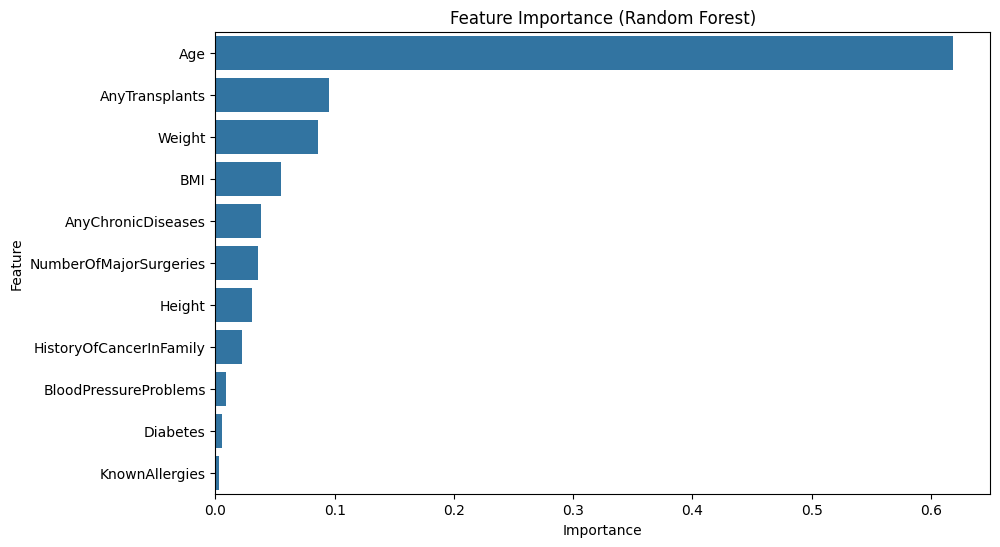

In [5]:
# Artifact: ML Modeling for Insurance Cost Prediction

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score  # Updated import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load dataset
data = pd.read_csv(r'C:\Users\mbpd1\Downloads\scaler\portfolio_project\data\insurance.csv')
data['BMI'] = data['Weight'] / (data['Height'] / 100) ** 2

# Features and target
X = data.drop('PremiumPrice', axis=1)
y = data['PremiumPrice']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
numerical_cols = ['Age', 'Height', 'Weight', 'BMI', 'NumberOfMajorSurgeries']
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

# Evaluate models
results = []
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    # Metrics
    rmse = root_mean_squared_error(y_test, y_pred)  # Replaced mean_squared_error with root_mean_squared_error
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    # Cross-validation
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'CV R² Mean': cv_scores.mean(),
        'CV R² Std': cv_scores.std()
    })
    # Save model (for deployment)
    if name == 'Random Forest':
        joblib.dump(model, r'C:\Users\mbpd1\Downloads\scaler\portfolio_project\app\random_forest_model.pkl')
        joblib.dump(scaler, r'C:\Users\mbpd1\Downloads\scaler\portfolio_project\app\scaler.pkl')

# Display results
results_df = pd.DataFrame(results)
print("Model Performance:\n", results_df)

# Feature Importance (Random Forest)
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance (Random Forest)')
plt.savefig(r'C:\Users\mbpd1\Downloads\scaler\portfolio_project\images\feature_importance.png')
plt.show()